In [1]:
import warnings
from collections import deque
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import gym
import torch.nn as nn
import torch


warnings.simplefilter('ignore')

In [2]:
module_path = os.path.abspath(os.path.join('../'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.agents.ppo import PPO

In [3]:
def _init_critic(state_dims: int) -> nn.Module:
  """
  Initalize the critic network for the PPO agent.

  Returns:
    nn.Module
  """
  return nn.Sequential(
    nn.Linear(state_dims, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 1)
  )
  pass

In [4]:
def _init_actor(state_dims: int, action_dims: int) -> nn.Module:
  """
  Initialize an actor network for the PPO agent.

  Returns:
    nn.Module
  """
  return nn.Sequential(
    nn.Linear(state_dims, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, action_dims),
    nn.Softmax(dim = -1)
  )
  pass

In [9]:
env = gym.make('CartPole-v1')
rewards_queue = deque()
rolling_mean_rewards = list()

max_episodes = 5000
max_trajectory_length = 200
update_timesteps = 500

state_space = env.observation_space.shape[0]
action_space = env.action_space.n

ppo = PPO(
  actor = _init_actor(state_space, action_space),
  critic = _init_critic(state_space),
  is_recurrent = False,
  actor_lr = 0.0025,
  critic_lr = 0.0025,
  epsilon_clipping = 0.1,
  optimization_steps = 5,
  discount_rate = 0.999
)

In [10]:
num_timesteps = 0

for epi in tqdm(range(max_episodes)):
    state, _ = env.reset()
    total_reward = 0.0

    for t in range(max_trajectory_length):
        num_timesteps += 1
        action, log_prob, state_value = ppo.select_action(torch.from_numpy(state.astype(np.float32)))
        state, reward, is_done, _, _ = env.step(action)
        ppo.record(state, action, log_prob, state_value, reward, is_done)
        total_reward += reward

        if is_done or update_timesteps == num_timesteps:
            break

    if update_timesteps == num_timesteps:
        ppo.update()
        num_timesteps = 0
        pass

    solved = total_reward > 195.0
    if len(rewards_queue) > 250:
        rewards_queue.popleft()

    rewards_queue.append(total_reward)
    rolling_mean_rewards.append(np.mean(rewards_queue))

    if solved:
        break

 63%|████████████████████████████████████████████████████████████▋                                    | 3129/5000 [01:56<01:09, 26.90it/s]


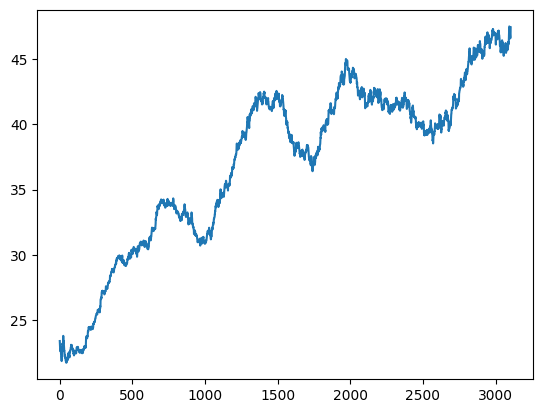

In [15]:
plt.plot(rolling_mean_rewards)

In [13]:
ppo.save('./models/ppo-cartpole-vanilla.pt')